# ETF AI预测策略 - 多模型实验回测对比

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '../code/src')
from backtest import run_backtest
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 配置参数

In [13]:
# 回测参数
year = 2026
START_DATE = f"{year}-04-01"
END_DATE = f"2026-05-05"
FIRST_REBALANCE_DATE = f"{year}-04-01"

DATA_PATH = "../etf_data/etf_74.csv"

# 自动扫描所有模型目录
BASE_DIR = "../model"
MODEL_TYPES = [
    "search_itransformer_74_3",
    "search_tcn_74_3",
]

EXPERIMENTS = []
for MODEL_TYPE in MODEL_TYPES:
    for exp_dir in sorted(glob.glob(f"{BASE_DIR}/{MODEL_TYPE}/exp_*")):
        # 添加 best_model_sliding.pth
        if os.path.exists(f"{exp_dir}/best_model_sliding.pth"):
            EXPERIMENTS.append((exp_dir, "best_model_sliding.pth"))
        # 添加 best_model.pth
        if os.path.exists(f"{exp_dir}/best_model.pth"):
            EXPERIMENTS.append((exp_dir, "best_model.pth"))
# 方法1：使用 pandas 日期范围
trading_days = pd.date_range(start=START_DATE, end=END_DATE, freq='B')  # B = business days
print(f"交易日数量: {len(trading_days)}")
print(f"回测期间: {START_DATE} ~ {END_DATE}")
print(f"数据路径: {DATA_PATH}")
print(f"实验数量: {len(EXPERIMENTS)}")

交易日数量: 25
回测期间: 2026-04-01 ~ 2026-05-05
数据路径: ../etf_data/etf_74.csv
实验数量: 158


## 运行回测 (数据只加载一次)

In [4]:
import pickle
import os
from tqdm import tqdm

results = []
CHECKPOINT_FILE = f"backtest_checkpoint_{year}.pkl"

# 加载已有断点
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        results = pickle.load(f)
    print(f"加载断点: 已完成 {len(results)} 个实验")

# 从断点位置继续
remaining_experiments = EXPERIMENTS[len(results):]

for exp_info in tqdm(remaining_experiments, desc="回测进度", total=len(remaining_experiments)):
    if isinstance(exp_info, tuple):
        exp_dir, model_file = exp_info
    else:
        exp_dir = exp_info
        model_file = "best_model_sliding.pth"
    
    exp_name = exp_dir.split('/')[-2] + '/' + exp_dir.split('/')[-1]
    
    try:
        result = run_backtest(
            model_dir=exp_dir,
            data_path=DATA_PATH,
            start_date=START_DATE,
            end_date=END_DATE,
            top_k=3,
            rebalance_days=5,
            position_pct=0.95,
            initial_capital=100000,
            commission=0.0003,
            first_rebalance_date=FIRST_REBALANCE_DATE,
            model_file=model_file,
            verbose=False,
            log=False
        )
        
        results.append({
            'experiment': exp_name,
            'model_file': model_file,
            'strategy_return': result.strategy_return,
            'hs300_return': result.hs300_return,
            'excess_return': result.excess_return,
            'max_drawdown': result.max_drawdown,
            'drawdown_days': result.drawdown_days,
            'recovery_days': result.recovery_days,
            'recovered': result.recovered
        })
        
    except Exception as e:
        print(f"\n失败: {exp_name}, 错误: {e}")
        results.append({
            'experiment': exp_name,
            'model_file': model_file,
            'strategy_return': np.nan,
            'hs300_return': np.nan,
            'excess_return': np.nan,
            'max_drawdown': np.nan,
            'drawdown_days': np.nan,
            'recovery_days': np.nan,
            'recovered': False
        })
    
    # 每完成一个实验保存断点
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(results, f)

print(f"\n全部完成，共 {len(results)} 个实验")

加载断点: 已完成 38 个实验


回测进度: 100%|██████████| 106/106 [05:17<00:00,  3.00s/it]


全部完成，共 144 个实验


## 结果汇总

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('strategy_return', ascending=False)
results_df = results_df.reset_index(drop=True)

display_df = results_df.copy()
display_df['策略收益'] = display_df['strategy_return'].apply(lambda x: f"{x:.2f}%")
display_df['HS300收益'] = display_df['hs300_return'].apply(lambda x: f"{x:.2f}%")
display_df['超额收益'] = display_df['excess_return'].apply(lambda x: f"{x:+.2f}%")
display_df['最大回撤'] = display_df['max_drawdown'].apply(lambda x: f"{x:.2f}%")
display_df['回撤天数'] = display_df['drawdown_days']
display_df['恢复天数'] = display_df['recovery_days']

print("=" * 80)
print("回测结果汇总 (按策略收益排序)")
print("=" * 80)
display_df[['experiment', 'model_file', '策略收益', 'HS300收益', '超额收益', '最大回撤', '回撤天数', '恢复天数']].head(20)

回测结果汇总 (按策略收益排序)


,experiment,model_file,策略收益,HS300收益,超额收益,最大回撤,回撤天数,恢复天数
0,model/search_itransformer_74_3\exp_54,best_model_sliding.pth,18.97%,6.40%,+12.57%,3.94%,1,7.0
1,model/search_itransformer_74_3\exp_54,best_model.pth,18.97%,6.40%,+12.57%,3.94%,1,7.0
2,model/search_itransformer_74_3\exp_64,best_model.pth,15.60%,6.40%,+9.21%,7.58%,3,10.0
3,model/search_itransformer_74_3\exp_6,best_model.pth,13.87%,6.40%,+7.47%,0.85%,3,NaN
4,model/search_itransformer_74_3\exp_6,best_model.pth,13.87%,6.40%,+7.47%,0.85%,3,NaN
5,model/search_itransformer_74_3\exp_37,best_model.pth,13.77%,6.40%,+7.38%,2.35%,2,3.0
6,model/search_itransformer_74_3\exp_55,best_model_sliding.pth,13.13%,6.40%,+6.74%,5.89%,1,13.0
7,model/search_itransformer_74_3\exp_35,best_model.pth,11.13%,6.40%,+4.73%,6.62%,3,13.0
8,model/search_itransformer_74_3\exp_55,best_model.pth,10.64%,6.40%,+4.24%,2.83%,1,5.0
9,model/search_itransformer_74_3\exp_30,best_model_sliding.pth,10.34%,6.40%,+3.95%,1.42%,1,4.0


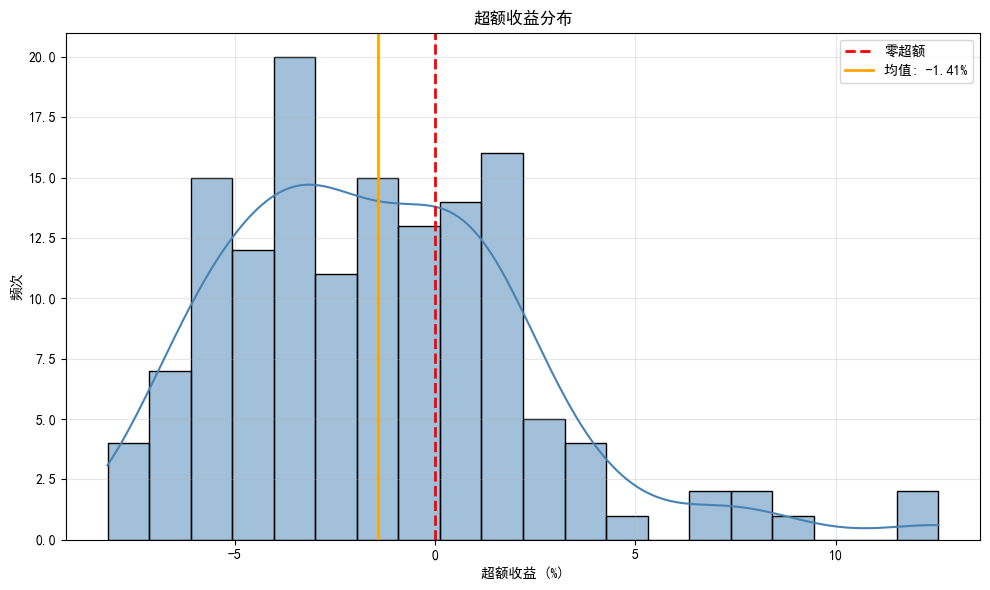

均值: -1.41%
正超额比例: 33.3%


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6))

# 直方图 + 密度曲线
sns.histplot(results_df['excess_return'], bins=20, kde=True, ax=ax, color='steelblue')

# 标记参考线
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='零超额')
ax.axvline(x=results_df['excess_return'].mean(), color='orange', linestyle='-', linewidth=2, 
           label=f"均值: {results_df['excess_return'].mean():.2f}%")

ax.set_xlabel('超额收益 (%)')
ax.set_ylabel('频次')
ax.set_title('超额收益分布')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印统计
print(f"均值: {results_df['excess_return'].mean():.2f}%")
print(f"正超额比例: {(results_df['excess_return'] > 0).sum() / len(results_df) * 100:.1f}%")

## 与训练指标相关性分析

正在提取 epoch 指标...
成功合并 288 个实验的数据

=== 训练指标与回测超额收益 (excess_return) 的相关性 ===


,Metric,Correlation
7,sliding_rank_ic,-0.1495
6,train_loss,-0.0866
12,weekly_ndcg,0.0721
3,weekly_excess_return,0.0721
1,weekly_score,0.0704
10,weekly_hit_rate,0.0674
5,eval_sliding_loss,0.0581
8,weekly_rank_ic,-0.0564
13,sliding_precision,-0.0551
4,eval_loss,0.0369


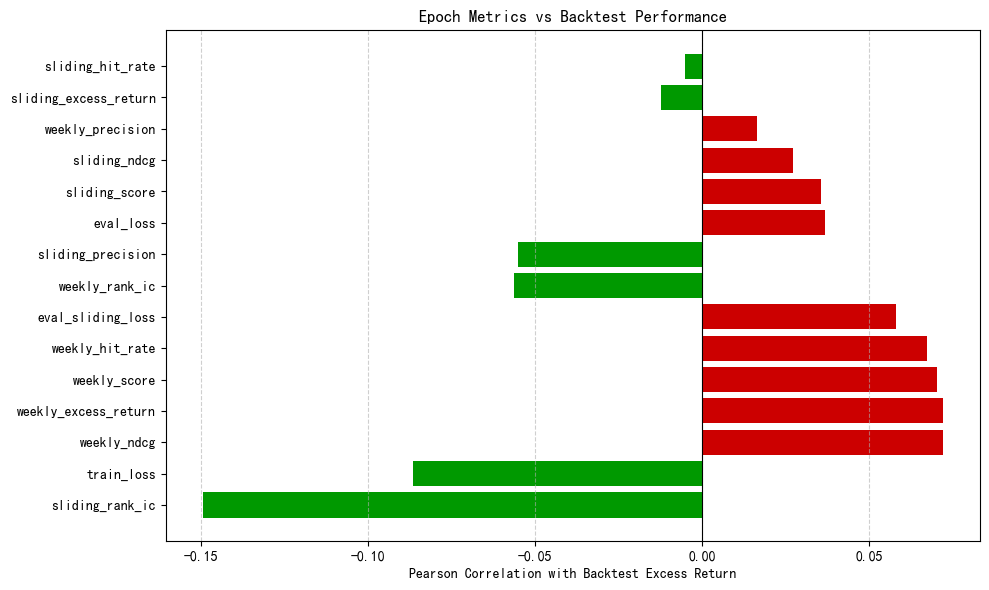

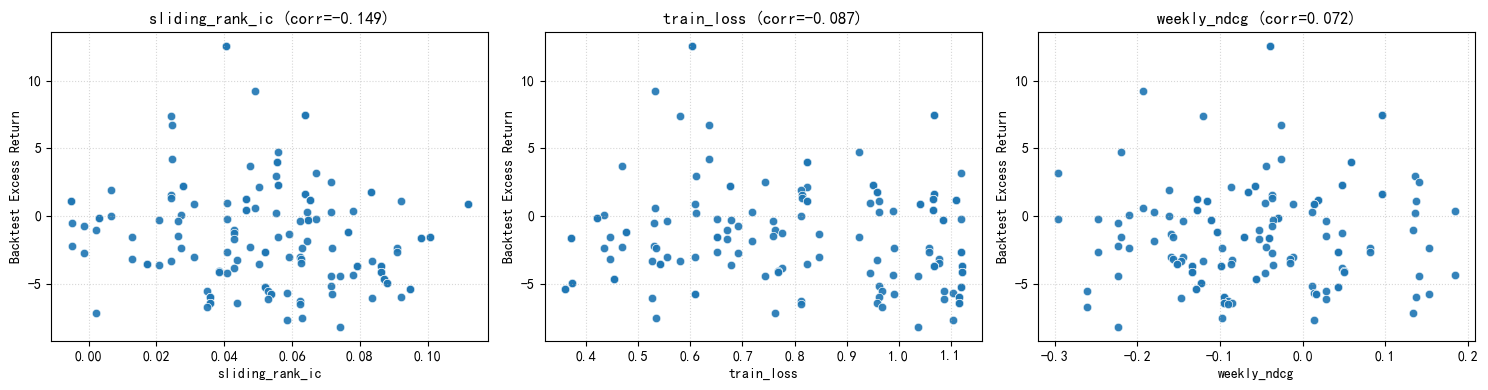

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 解析每个实验的 epoch_scores.txt
def get_last_epoch_metrics(exp_path):
    txt_path = os.path.join(exp_path, 'epoch_scores.txt')
    if not os.path.exists(txt_path):
        return None
    try:
        df = pd.read_csv(txt_path)
        return df.iloc[-1].to_dict()
    except Exception as e:
        print(f"解析 {txt_path} 失败: {e}")
        return None

def get_exp_key(exp_path):
    parent = os.path.basename(os.path.dirname(exp_path))
    name = os.path.basename(exp_path)
    return f"{parent}/{name}".replace('\\', '/')

print("正在提取 epoch 指标...")
epoch_metrics_list = []

for exp_info in EXPERIMENTS:
    if isinstance(exp_info, tuple):
        exp_dir, model_file = exp_info
    else:
        exp_dir = exp_info
        model_file = "best_model_sliding.pth"
    
    metrics = get_last_epoch_metrics(exp_dir)
    if metrics:
        metrics['exp_key'] = get_exp_key(exp_dir)
        epoch_metrics_list.append(metrics)

df_epoch = pd.DataFrame(epoch_metrics_list)

# 2. 合并 results_df 和 epoch_metrics
# 统一 results_df 中的 experiment 列为 exp_key 格式
results_df['exp_key'] = results_df['experiment'].str.replace('\\', '/').apply(lambda x: x.split('/')[-2] + '/' + x.split('/')[-1] if '/' in x else x)

merged_df = results_df.merge(df_epoch, on='exp_key', how='left')
merged_df = merged_df.dropna(subset=['sliding_score'])
print(f"成功合并 {len(merged_df)} 个实验的数据")

# 3. 计算相关性
metrics_cols = [
    'sliding_score', 'weekly_score', 
    'sliding_excess_return', 'weekly_excess_return',
    'eval_loss', 'eval_sliding_loss', 'train_loss',
    'sliding_rank_ic', 'weekly_rank_ic',
    'sliding_hit_rate', 'weekly_hit_rate',
    'sliding_ndcg', 'weekly_ndcg',
    'sliding_precision', 'weekly_precision'
]

valid_cols = [c for c in metrics_cols if c in merged_df.columns]

print("\n=== 训练指标与回测超额收益 (excess_return) 的相关性 ===")
correlations = []
for col in valid_cols:
    corr = merged_df[col].corr(merged_df['excess_return'])
    correlations.append({'Metric': col, 'Correlation': corr})

df_corr = pd.DataFrame(correlations).sort_values('Correlation', key=abs, ascending=False)
display(df_corr.style.format({'Correlation': '{:.4f}'}).background_gradient(cmap='RdYlGn', subset=['Correlation']))

# 4. 可视化
plt.figure(figsize=(10, 6))
colors = ['#cc0000' if x > 0 else '#009900' for x in df_corr['Correlation']]
bars = plt.barh(df_corr['Metric'], df_corr['Correlation'], color=colors)
plt.xlabel('Pearson Correlation with Backtest Excess Return')
plt.title('Epoch Metrics vs Backtest Performance')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

top_metrics = df_corr.head(3)['Metric'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(top_metrics):
    ax = axes[i]
    ax.scatter(merged_df[metric], merged_df['excess_return'], alpha=0.7, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_ylabel('Backtest Excess Return')
    ax.set_title(f'{metric} (corr={df_corr[df_corr["Metric"]==metric]["Correlation"].values[0]:.3f})')
    ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 详细性能指标 (Top 20)

正在提取 epoch 指标...
成功合并 0 个实验的数据

=== 训练指标与回测超额收益 (excess_return) 的相关性 ===


,Metric,Correlation
0,sliding_score,nan
1,weekly_score,nan
2,sliding_excess_return,nan
3,weekly_excess_return,nan
4,eval_loss,nan
5,eval_sliding_loss,nan
6,train_loss,nan
7,sliding_rank_ic,nan
8,weekly_rank_ic,nan
9,sliding_hit_rate,nan


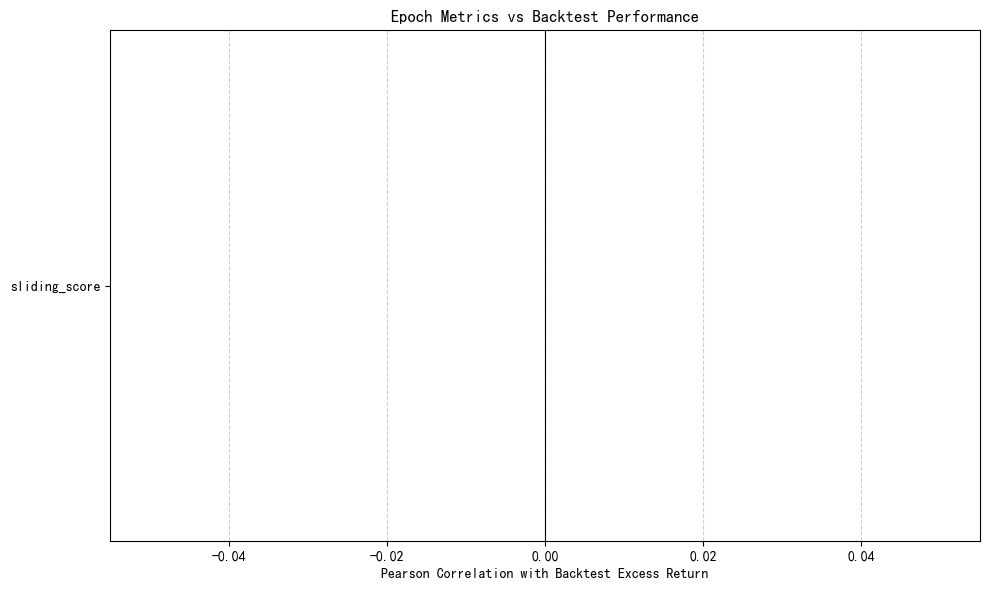

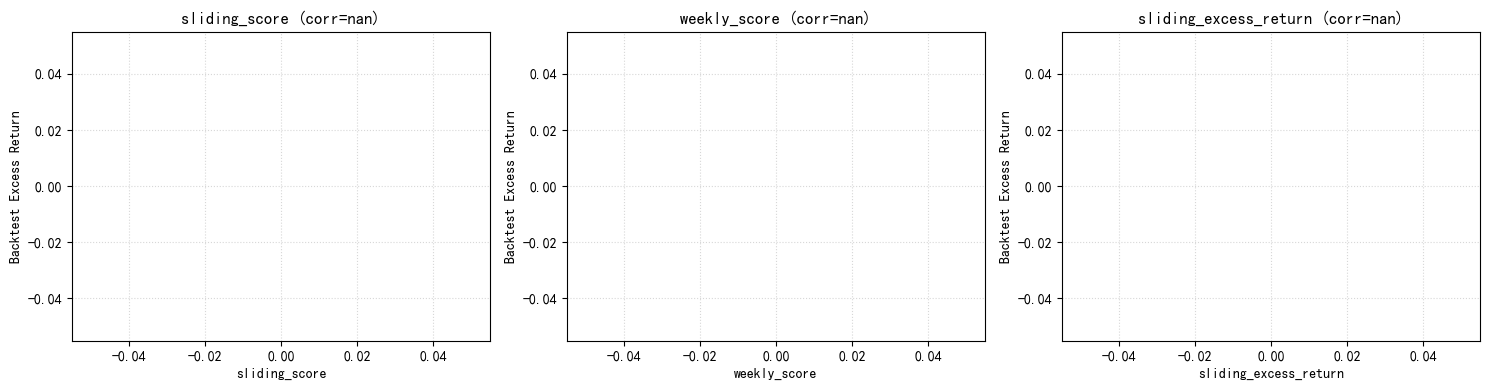

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 解析每个实验的 epoch_scores.txt
def get_last_epoch_metrics(exp_path):
    txt_path = os.path.join(exp_path, 'epoch_scores.txt')
    if not os.path.exists(txt_path):
        return None
    try:
        df = pd.read_csv(txt_path)
        # 取最后一行（最终状态）
        return df.iloc[-1].to_dict()
    except Exception as e:
        print(f"解析 {txt_path} 失败: {e}")
        return None

print("正在提取 epoch 指标...")
epoch_metrics_list = []

# 遍历 EXPERIMENTS 列表提取指标
for exp_info in EXPERIMENTS:
    if isinstance(exp_info, tuple):
        exp_dir, model_file = exp_info
    else:
        exp_dir = exp_info
        model_file = "best_model_sliding.pth"
    
    exp_name = exp_dir.replace('\\', '/')  # 统一路径格式
    metrics = get_last_epoch_metrics(exp_dir)
    if metrics:
        metrics['exp_dir'] = exp_name
        epoch_metrics_list.append(metrics)

df_epoch = pd.DataFrame(epoch_metrics_list)

# 2. 合并 results_df 和 epoch_metrics
# results_df 中的 experiment 列需要统一格式
results_df['exp_dir_norm'] = results_df['experiment'].str.replace('\\', '/')

# 合并: left join from results_df
merged_df = results_df.merge(df_epoch, left_on='exp_dir_norm', right_on='exp_dir', how='left')

# 过滤掉解析失败的行
merged_df = merged_df.dropna(subset=['sliding_score'])
print(f"成功合并 {len(merged_df)} 个实验的数据")

# 3. 计算相关性
# 选择 epoch_scores 中感兴趣的指标列 (排除 epoch, lr, time 等)
metrics_cols = [
    'sliding_score', 'weekly_score', 
    'sliding_excess_return', 'weekly_excess_return',
    'eval_loss', 'eval_sliding_loss', 'train_loss',
    'sliding_rank_ic', 'weekly_rank_ic',
    'sliding_hit_rate', 'weekly_hit_rate',
    'sliding_ndcg', 'weekly_ndcg',
    'sliding_precision', 'weekly_precision'
]

# 确保列存在
valid_cols = [c for c in metrics_cols if c in merged_df.columns]

print("\n=== 训练指标与回测超额收益 (excess_return) 的相关性 ===")
correlations = []
for col in valid_cols:
    corr = merged_df[col].corr(merged_df['excess_return'])
    correlations.append({'Metric': col, 'Correlation': corr})

df_corr = pd.DataFrame(correlations).sort_values('Correlation', key=abs, ascending=False)
display(df_corr.style.format({'Correlation': '{:.4f}'}).background_gradient(cmap='RdYlGn', subset=['Correlation']))

# 4. 可视化
plt.figure(figsize=(10, 6))
colors = ['#cc0000' if x > 0 else '#009900' for x in df_corr['Correlation']]
bars = plt.barh(df_corr['Metric'], df_corr['Correlation'], color=colors)
plt.xlabel('Pearson Correlation with Backtest Excess Return')
plt.title('Epoch Metrics vs Backtest Performance')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 打印 Top 3 相关指标的详细散点图
top_metrics = df_corr.head(3)['Metric'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(top_metrics):
    ax = axes[i]
    ax.scatter(merged_df[metric], merged_df['excess_return'], alpha=0.7, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_ylabel('Backtest Excess Return')
    ax.set_title(f'{metric} (corr={df_corr[df_corr["Metric"]==metric]["Correlation"].values[0]:.3f})')
    ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 详细性能指标 (Top 20)

In [9]:
# 计算综合得分
results_df['score'] = (
    results_df['strategy_return'] * 0.4 +
    results_df['excess_return'] * 0.3 -
    results_df['max_drawdown'] * 0.3
)

results_df_sorted = results_df.sort_values('score', ascending=False)

print("=" * 80)
print("综合评分排名 (策略收益40% + 超额收益30% - 最大回撤30%)")
print("=" * 80)
for i, row in results_df_sorted.head(20).iterrows():
    print(f"\n{row['experiment']} ({row['model_file']})")
    print(f"  策略收益: {row['strategy_return']:.2f}%")
    print(f"  超额收益: {row['excess_return']:.2f}%")
    print(f"  最大回撤: {row['max_drawdown']:.2f}%")
    print(f"  综合得分: {row['score']:.2f}")

综合评分排名 (策略收益40% + 超额收益30% - 最大回撤30%)

model/search_itransformer_74_3\exp_54 (best_model_sliding.pth)
  策略收益: 18.97%
  超额收益: 12.57%
  最大回撤: 3.94%
  综合得分: 10.17

model/search_itransformer_74_3\exp_54 (best_model.pth)
  策略收益: 18.97%
  超额收益: 12.57%
  最大回撤: 3.94%
  综合得分: 10.17

model/search_itransformer_74_3\exp_6 (best_model.pth)
  策略收益: 13.87%
  超额收益: 7.47%
  最大回撤: 0.85%
  综合得分: 7.53

model/search_itransformer_74_3\exp_6 (best_model.pth)
  策略收益: 13.87%
  超额收益: 7.47%
  最大回撤: 0.85%
  综合得分: 7.53

model/search_itransformer_74_3\exp_37 (best_model.pth)
  策略收益: 13.77%
  超额收益: 7.38%
  最大回撤: 2.35%
  综合得分: 7.02

model/search_itransformer_74_3\exp_64 (best_model.pth)
  策略收益: 15.60%
  超额收益: 9.21%
  最大回撤: 7.58%
  综合得分: 6.73

model/search_itransformer_74_3\exp_55 (best_model_sliding.pth)
  策略收益: 13.13%
  超额收益: 6.74%
  最大回撤: 5.89%
  综合得分: 5.51

model/search_itransformer_74_3\exp_30 (best_model_sliding.pth)
  策略收益: 10.34%
  超额收益: 3.95%
  最大回撤: 1.42%
  综合得分: 4.90

model/search_itransformer_74_3\exp_30 (b

## 保存结果

In [10]:
results_df.to_csv(f'backtest_results_{year}.csv', index=False, encoding='utf-8-sig')
print(f"结果已保存: backtest_results_{year}.csv")

结果已保存: backtest_results_2026.csv
